<h1>Image Detection Neural Network</h1>
<p>Neural Network implementation utilizing PyTorch on the Cifar-10 Pytorch Dataset.</p>

<h2>Parsing Data and Preprocessing</h2>

In [294]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt


#Loads CIFAR10 Dataset and transforms images into tensor objects
training_data = datasets.CIFAR10(
    root="data", #path where the train data is stored
    train=True, #specifies training set
    download=True, #downloads from interenet if not available
    transform=ToTensor() #feature and label transformations
)

#Parameters are same as above
test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

C:\Users\jmfra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [127]:
# Image as Tensor and associated label
print(training_data[0])
# Tensor Shape
print(training_data[0][0].size())

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0

<h2>Visualizing Data</h2>

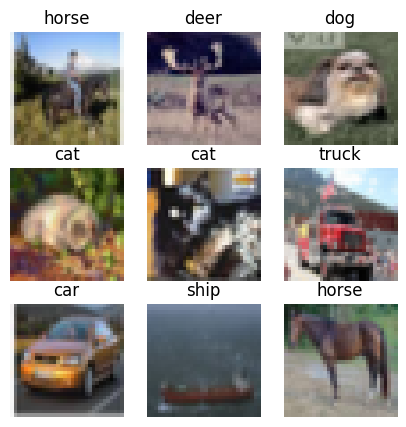

In [111]:
labels_map = {
    0: "plane",
    1: "car",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

figure = plt.figure(figsize=(5, 5)) #figure for displaying examples in data
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item() #grabbing index of random data
    img, label = training_data[sample_idx] #tuple of the image and label we grabbed
    figure.add_subplot(rows, cols, i) #section of figure we are adding to
    plt.title(labels_map[label]) #title determined from label_map 
    plt.axis("off") #removes axis from plots (not needed for images)
    plt.imshow(np.transpose(img, (1,2,0))) #fits image to subplot in correct orientation
plt.show()

<h2>Model Implementation</h2>

In [437]:
##Imports for building network
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(32*32*3, 512), # Hidden Layer 1, 32*32*3 features, 512 Neurons
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,256), # Output Layer
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self, x):
        x = self.flatten(x) 
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
# Full Implementation of Train / Test Loop

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y) 

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()



def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

<h2>Model Training</h2>

In [439]:
learning_rate = 1e-3
batch_size = 64
epochs = 100
current = 0

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 47.2%, Avg loss: 1.490047 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 46.4%, Avg loss: 1.490443 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 47.6%, Avg loss: 1.475300 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 46.6%, Avg loss: 1.485278 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 46.2%, Avg loss: 1.531938 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 48.3%, Avg loss: 1.457972 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 48.0%, Avg loss: 1.462501 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 48.3%, Avg loss: 1.458308 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 48.6%, Avg loss: 1.450094 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 48.6%, Avg loss: 1.449633 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 48.4%, Avg los

In [441]:
torch.save(model.state_dict(), 'model_weights.pth')

In [440]:
test_loop(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 50.6%, Avg loss: 1.410239 



<h2>Test Example</h2>

Feature batch shape: torch.Size([64, 3, 32, 32])
Labels batch shape: torch.Size([64])


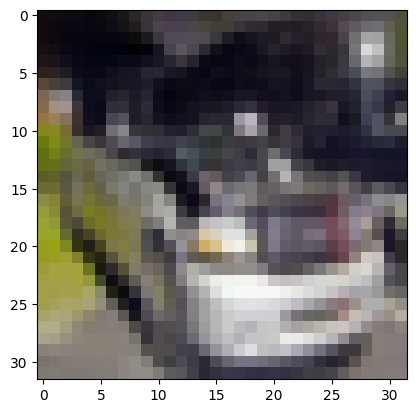

Label: car 1
tensor([0.0153, 0.0315, 0.1817, 0.2469, 0.0774, 0.2549, 0.0092, 0.1658, 0.0070,
        0.0103])
tensor([5, 7, 2, 0, 1, 7, 3, 1, 6, 2, 7, 8, 0, 0, 9, 7, 2, 0, 2, 5, 2, 7, 2, 7,
        7, 0, 0, 1, 0, 3, 3, 4, 5, 6, 2, 2, 2, 5, 0, 9, 4, 2, 4, 2, 9, 2, 0, 5,
        2, 0, 8, 8, 5, 0, 1, 7, 9, 6, 9, 7, 7, 7, 4, 3])
3


In [ ]:

# Display image and label.
test_features, test_labels = next(iter(test_dataloader))
print(f"Feature batch shape: {test_features.size()}")
print(f"Labels batch shape: {test_labels.size()}")
img = test_features[0].squeeze()
label = test_labels[0]
plt.imshow(np.transpose(img, (1,2,0)))
plt.show()
print(f"Label: {labels_map[label.item()]} {label}")

with torch.no_grad():  
    pred = model(test_features)
    softmax = nn.Softmax(dim=1)
    print(pred_probab[0])
    y_pred = pred_probab.argmax(1)
    print(y_pred)
    print(y_pred.sum().item() // 64)
    